# 08 — SVM y Random Forest con Optuna

Segundo modelo del proyecto. Objetivos:
1. Entrenar SVM (kernel RBF/poly) y Random Forest con búsqueda Optuna.
2. Optimizar `recall_critico` (> 0.85) como métrica primaria.
3. Registrar experimentos en MLflow (DagsHub), versionar modelos con DVC.
4. Comparar contra baseline logístico (notebook 07).

## Métricas del proyecto
| Métrica | Umbral |
|---------|--------|
| `recall_critico` | > 0.85 |
| `precision_critico` | > 0.70 |
| `f1_macro` | > 0.65 |

## 1. Imports y configuración

In [1]:
import os
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, learning_curve
from sklearn.svm import SVC

from sonalert.config import FIGURES_DIR, MODELS_DIR, PROCESSED_DATA_DIR, PROJ_ROOT

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
CLASS_NAMES = ["bajo", "medio", "alto", "critico"]
CRITICO = 3
N_TRIALS_SVM = 50
N_TRIALS_RF = 100

2026-05-19 18:19:55.937 | INFO     | sonalert.config:<module>:11 - PROJ_ROOT path is: /lustre/home/estudiante_57/sonAlert


In [2]:
MLFLOW_URI = os.environ.get("MLFLOW_TRACKING_URI")
MLFLOW_ACTIVE = bool(MLFLOW_URI)

if MLFLOW_ACTIVE:
    import mlflow
    import mlflow.sklearn

    mlflow.set_tracking_uri(MLFLOW_URI)
    mlflow.set_experiment("svm_rf_optuna")
    print(f"[MLflow] activo: {MLFLOW_URI}")
else:
    print("[MLflow] inactivo — figuras y modelos se guardan localmente.")

[MLflow] activo: https://dagshub.com/RovleZMex/sonAlert.mlflow


## 2. Cargar splits preprocesados

In [3]:
import subprocess
subprocess.run(["dvc", "pull"], cwd="/lustre/home/estudiante_57/sonAlert")

# Verificar si los parquets llegaron
from pathlib import Path
processed = Path("/lustre/home/estudiante_57/sonAlert/data/processed")
print(list(processed.glob("*.parquet")))

[PosixPath('/lustre/home/estudiante_57/sonAlert/data/processed/X_val.parquet'), PosixPath('/lustre/home/estudiante_57/sonAlert/data/processed/y_holdout.parquet'), PosixPath('/lustre/home/estudiante_57/sonAlert/data/processed/panel_features.parquet'), PosixPath('/lustre/home/estudiante_57/sonAlert/data/processed/X_train.parquet'), PosixPath('/lustre/home/estudiante_57/sonAlert/data/processed/y_train.parquet'), PosixPath('/lustre/home/estudiante_57/sonAlert/data/processed/X_holdout.parquet'), PosixPath('/lustre/home/estudiante_57/sonAlert/data/processed/splits_meta.parquet'), PosixPath('/lustre/home/estudiante_57/sonAlert/data/processed/y_val.parquet')]


md5: 7cae867de7959c5f55ab095952ee0d0b
md5: 0790bd3c767d0f0c2634929737d3c986
ERROR: failed to pull data from the cloud - Can't remove the following unsaved files without confirmation. Use `--force` to force.
/lustre/home/estudiante_57/sonAlert/models/preprocessor.joblib


In [4]:
X_train   = pd.read_parquet(PROCESSED_DATA_DIR / "X_train.parquet")
X_val     = pd.read_parquet(PROCESSED_DATA_DIR / "X_val.parquet")
X_holdout = pd.read_parquet(PROCESSED_DATA_DIR / "X_holdout.parquet")

y_train   = pd.read_parquet(PROCESSED_DATA_DIR / "y_train.parquet")["y"]
y_val     = pd.read_parquet(PROCESSED_DATA_DIR / "y_val.parquet")["y"]
y_holdout = pd.read_parquet(PROCESSED_DATA_DIR / "y_holdout.parquet")["y"]

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
print(f"X_holdout: {X_holdout.shape} | y_holdout: {y_holdout.shape}")
print(f"\nClass balance train: {dict(y_train.value_counts(normalize=True).sort_index().round(3))}")

X_train: (6912, 141) | y_train: (6912,)
X_val:   (864, 141)   | y_val:   (864,)
X_holdout: (864, 141) | y_holdout: (864,)

Class balance train: {0: np.float64(0.643), 1: np.float64(0.222), 2: np.float64(0.07), 3: np.float64(0.065)}


## 3. Scorers y función de evaluación

In [5]:
scorers = {
    "recall_critico":    make_scorer(recall_score, labels=[CRITICO], average="macro", zero_division=0),
    "precision_critico": make_scorer(precision_score, labels=[CRITICO], average="macro", zero_division=0),
    "f1_macro":          make_scorer(f1_score, average="macro", zero_division=0),
    "accuracy":          "accuracy",
}
PRIMARY_METRIC = "recall_critico"


def evaluate(model, X, y, split_name: str) -> tuple:
    y_pred = model.predict(X)
    metrics = {
        f"{split_name}_recall_critico":    recall_score(y, y_pred, labels=[CRITICO], average="macro", zero_division=0),
        f"{split_name}_precision_critico": precision_score(y, y_pred, labels=[CRITICO], average="macro", zero_division=0),
        f"{split_name}_f1_macro":          f1_score(y, y_pred, average="macro", zero_division=0),
        f"{split_name}_accuracy":          float((y_pred == y).mean()),
    }
    print(f"\n=== {split_name.upper()} ===")
    print(classification_report(y, y_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))
    for k, v in metrics.items():
        print(f"  {k}: {v:.3f}")
    return metrics, y_pred


print(f"Métrica primaria: {PRIMARY_METRIC}")

Métrica primaria: recall_critico


## 4. SVM con Optuna

**Espacio de búsqueda:**
- `C`: log-uniform [1e-3, 1e3]
- `kernel`: rbf / poly
- `gamma`: log-uniform [1e-4, 1e1] (solo rbf)
- `degree`: int [2, 4] (solo poly)
- `class_weight`: balanced / None

In [6]:
tscv = TimeSeriesSplit(n_splits=5)


def svm_objective(trial: optuna.Trial) -> float:
    kernel = trial.suggest_categorical("kernel", ["rbf", "poly"])
    params = {
        "C":            trial.suggest_float("C", 1e-3, 1e3, log=True),
        "kernel":       kernel,
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
        "random_state": RANDOM_STATE,
        "probability":  False,
    }
    if kernel == "rbf":
        params["gamma"] = trial.suggest_float("gamma", 1e-4, 1e1, log=True)
    elif kernel == "poly":
        params["degree"] = trial.suggest_int("degree", 2, 4)
        params["gamma"]  = "scale"

    model = SVC(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=tscv,
        scoring=scorers[PRIMARY_METRIC],
        n_jobs=-1,
    )
    return scores.mean()

In [7]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
svm_study = optuna.create_study(direction="maximize", sampler=sampler, study_name="svm_optuna")
svm_study.optimize(svm_objective, n_trials=N_TRIALS_SVM, show_progress_bar=True)

print(f"\nMejor trial SVM:")
print(f"  CV {PRIMARY_METRIC}: {svm_study.best_value:.4f}")
print(f"  Params: {svm_study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Mejor trial SVM:
  CV recall_critico: 0.9475
  Params: {'kernel': 'rbf', 'C': 29.66615596264863, 'class_weight': 'balanced', 'gamma': 0.035496471242832714}


In [8]:
best_svm_params = svm_study.best_params.copy()
best_svm_params["random_state"] = RANDOM_STATE
svm_best = SVC(**best_svm_params)
svm_best.fit(X_train, y_train)

svm_metrics_val,     y_val_pred_svm     = evaluate(svm_best, X_val,     y_val,     "val")
svm_metrics_holdout, y_holdout_pred_svm = evaluate(svm_best, X_holdout, y_holdout, "holdout")


=== VAL ===
              precision    recall  f1-score   support

        bajo      0.989     0.966     0.977       561
       medio      0.880     0.836     0.857       201
        alto      0.333     0.094     0.147        53
     critico      0.427     0.959     0.591        49

    accuracy                          0.882       864
   macro avg      0.657     0.714     0.643       864
weighted avg      0.892     0.882     0.877       864

  val_recall_critico: 0.959
  val_precision_critico: 0.427
  val_f1_macro: 0.643
  val_accuracy: 0.882

=== HOLDOUT ===
              precision    recall  f1-score   support

        bajo      0.977     0.938     0.957       580
       medio      0.832     0.806     0.819       196
        alto      0.467     0.135     0.209        52
     critico      0.353     1.000     0.522        36

    accuracy                          0.862       864
   macro avg      0.657     0.720     0.627       864
weighted avg      0.887     0.862     0.862       86

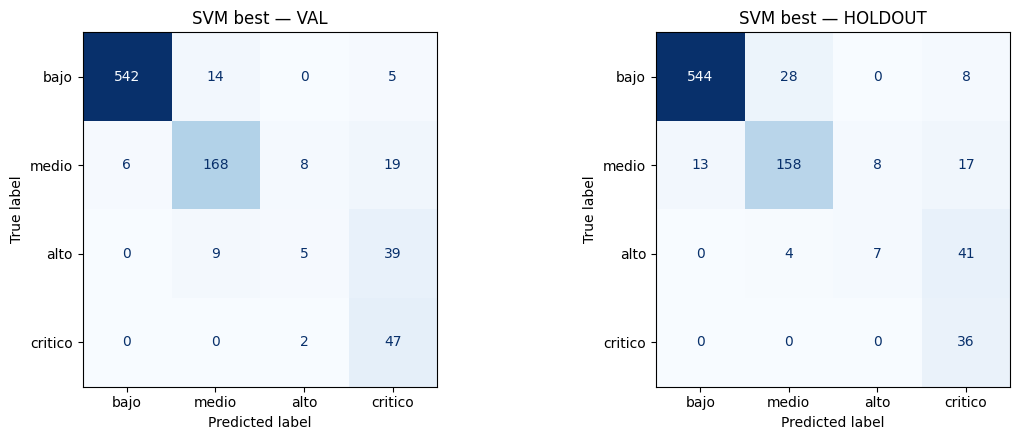

Guardado: reports/figures/08_svm_confusion.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (y_true, y_pred, title) in zip(
    axes,
    [(y_val, y_val_pred_svm, "VAL"), (y_holdout, y_holdout_pred_svm, "HOLDOUT")],
):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d"
    )
    ax.set_title(f"SVM best — {title}")
plt.tight_layout()
svm_cm_path = FIGURES_DIR / "08_svm_confusion.png"
plt.savefig(svm_cm_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {svm_cm_path.relative_to(PROJ_ROOT)}")

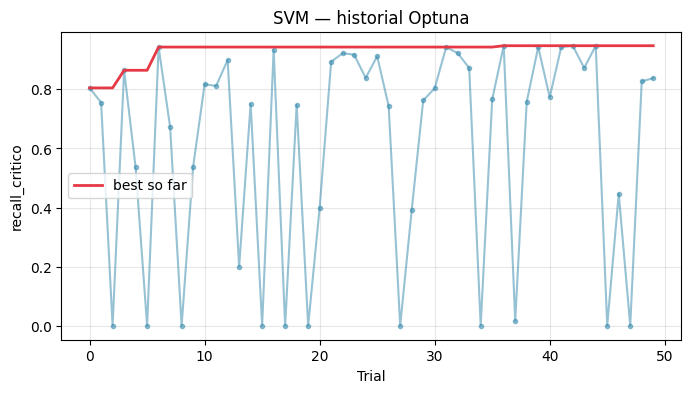

Guardado: reports/figures/08_svm_optuna_history.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
trials_df = svm_study.trials_dataframe()
ax.plot(trials_df.index, trials_df["value"], alpha=0.5, marker=".", color="#2E86AB")
best_so_far = trials_df["value"].cummax()
ax.plot(trials_df.index, best_so_far, color="#E63946", linewidth=2, label="best so far")
ax.set_xlabel("Trial")
ax.set_ylabel(PRIMARY_METRIC)
ax.set_title("SVM — historial Optuna")
ax.legend()
ax.grid(alpha=0.3)
svm_hist_path = FIGURES_DIR / "08_svm_optuna_history.png"
plt.savefig(svm_hist_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {svm_hist_path.relative_to(PROJ_ROOT)}")

In [11]:
svm_model_path = MODELS_DIR / "svm_best.joblib"
joblib.dump(svm_best, svm_model_path)
print(f"Modelo SVM guardado: {svm_model_path.relative_to(PROJ_ROOT)}")

Modelo SVM guardado: models/svm_best.joblib


## 5. Random Forest con Optuna

**Espacio de búsqueda:**
- `n_estimators`: int [50, 500]
- `max_depth`: int [5, 30] o None
- `min_samples_split`: int [2, 20]
- `min_samples_leaf`: int [1, 10]
- `max_features`: sqrt / log2
- `class_weight`: balanced / balanced_subsample / None

In [12]:
def rf_objective(trial: optuna.Trial) -> float:
    use_max_depth = trial.suggest_categorical("use_max_depth", [True, False])
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 500),
        "max_depth":         trial.suggest_int("max_depth", 5, 30) if use_max_depth else None,
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "class_weight":      trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample", None]),
        "n_jobs":            -1,
        "random_state":      RANDOM_STATE,
    }
    model = RandomForestClassifier(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=tscv,
        scoring=scorers[PRIMARY_METRIC],
        n_jobs=1,
    )
    return scores.mean()

In [13]:
rf_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="rf_optuna",
)
rf_study.optimize(rf_objective, n_trials=N_TRIALS_RF, show_progress_bar=True)

print(f"\nMejor trial RF:")
print(f"  CV {PRIMARY_METRIC}: {rf_study.best_value:.4f}")
print(f"  Params: {rf_study.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]


Mejor trial RF:
  CV recall_critico: 0.8695
  Params: {'use_max_depth': True, 'n_estimators': 208, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced'}


In [14]:
best_rf_params = {
    k: v for k, v in rf_study.best_params.items() if k != "use_max_depth"
}
if not rf_study.best_params["use_max_depth"]:
    best_rf_params["max_depth"] = None
best_rf_params["n_jobs"] = -1
best_rf_params["random_state"] = RANDOM_STATE

rf_best = RandomForestClassifier(**best_rf_params)
rf_best.fit(X_train, y_train)

rf_metrics_val,     y_val_pred_rf     = evaluate(rf_best, X_val,     y_val,     "val")
rf_metrics_holdout, y_holdout_pred_rf = evaluate(rf_best, X_holdout, y_holdout, "holdout")


=== VAL ===
              precision    recall  f1-score   support

        bajo      0.993     0.982     0.987       561
       medio      0.886     0.965     0.924       201
        alto      0.842     0.604     0.703        53
     critico      0.885     0.939     0.911        49

    accuracy                          0.953       864
   macro avg      0.901     0.872     0.881       864
weighted avg      0.953     0.953     0.951       864

  val_recall_critico: 0.939
  val_precision_critico: 0.885
  val_f1_macro: 0.881
  val_accuracy: 0.953

=== HOLDOUT ===
              precision    recall  f1-score   support

        bajo      0.996     0.967     0.982       580
       medio      0.859     0.934     0.895       196
        alto      0.727     0.769     0.748        52
     critico      0.970     0.889     0.928        36

    accuracy                          0.944       864
   macro avg      0.888     0.890     0.888       864
weighted avg      0.948     0.944     0.946       86

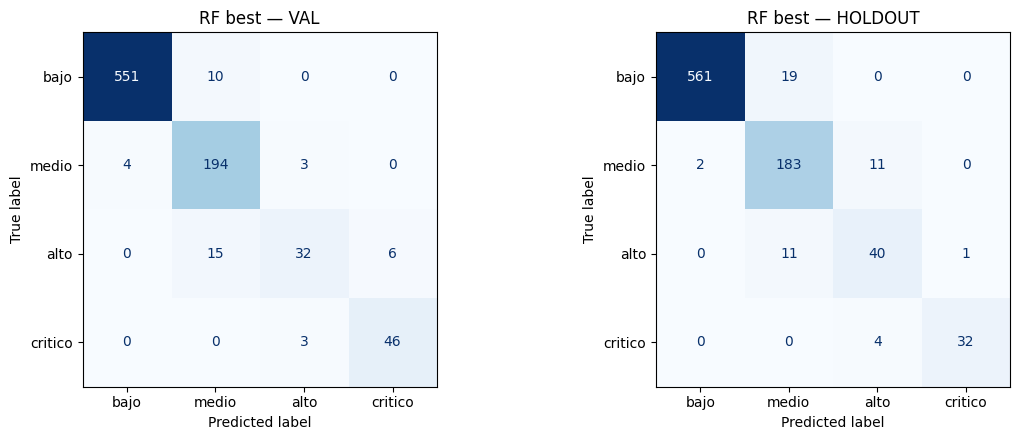

Guardado: reports/figures/08_rf_confusion.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (y_true, y_pred, title) in zip(
    axes,
    [(y_val, y_val_pred_rf, "VAL"), (y_holdout, y_holdout_pred_rf, "HOLDOUT")],
):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d"
    )
    ax.set_title(f"RF best — {title}")
plt.tight_layout()
rf_cm_path = FIGURES_DIR / "08_rf_confusion.png"
plt.savefig(rf_cm_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {rf_cm_path.relative_to(PROJ_ROOT)}")

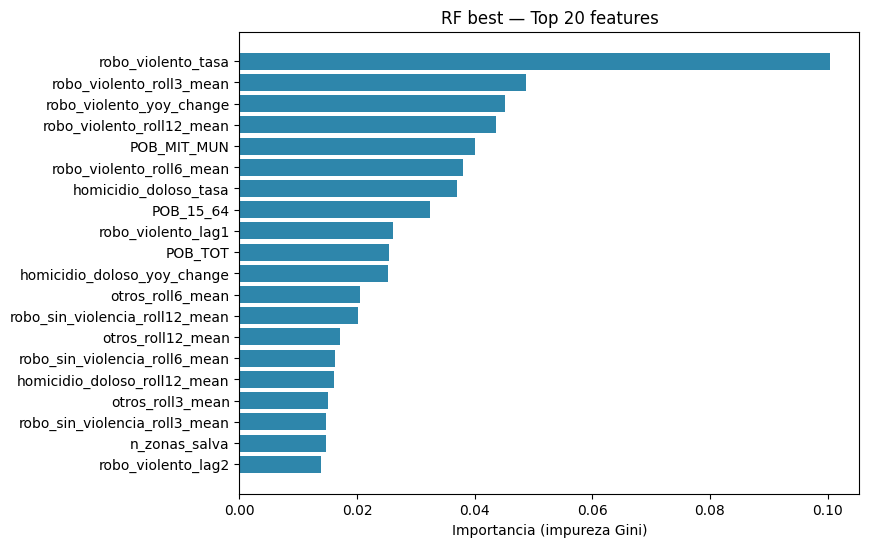

Guardado: reports/figures/08_rf_feature_importance.png


In [16]:
feat_imp = pd.Series(rf_best.feature_importances_, index=X_train.columns)
top20 = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20.index[::-1], top20.values[::-1], color="#2E86AB")
ax.set_xlabel("Importancia (impureza Gini)")
ax.set_title("RF best — Top 20 features")
rf_fi_path = FIGURES_DIR / "08_rf_feature_importance.png"
plt.savefig(rf_fi_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {rf_fi_path.relative_to(PROJ_ROOT)}")

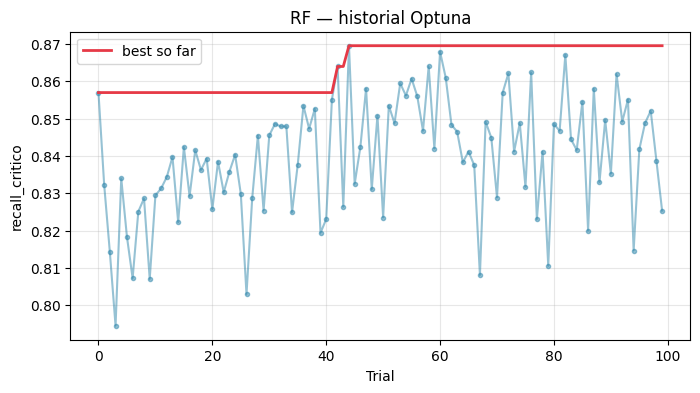

Guardado: reports/figures/08_rf_optuna_history.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
rf_trials_df = rf_study.trials_dataframe()
ax.plot(rf_trials_df.index, rf_trials_df["value"], alpha=0.5, marker=".", color="#2E86AB")
ax.plot(rf_trials_df.index, rf_trials_df["value"].cummax(), color="#E63946", linewidth=2, label="best so far")
ax.set_xlabel("Trial")
ax.set_ylabel(PRIMARY_METRIC)
ax.set_title("RF — historial Optuna")
ax.legend()
ax.grid(alpha=0.3)
rf_hist_path = FIGURES_DIR / "08_rf_optuna_history.png"
plt.savefig(rf_hist_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {rf_hist_path.relative_to(PROJ_ROOT)}")

In [18]:
rf_model_path = MODELS_DIR / "rf_best.joblib"
joblib.dump(rf_best, rf_model_path)
print(f"Modelo RF guardado: {rf_model_path.relative_to(PROJ_ROOT)}")

Modelo RF guardado: models/rf_best.joblib


## 6. Curvas de aprendizaje

Diagnóstico bias/variance: ¿se beneficiaría de más datos? ¿underfit u overfit?

In [19]:
def plot_learning_curve(estimator, title: str, save_path: Path) -> None:
    train_sizes = np.linspace(0.1, 1.0, 8)
    sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X_train,
        y=y_train,
        train_sizes=train_sizes,
        cv=TimeSeriesSplit(n_splits=5),
        scoring=scorers[PRIMARY_METRIC],
        n_jobs=-1,
        shuffle=False,
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sizes, train_scores.mean(axis=1), "o-", label="train", color="#2E86AB")
    ax.fill_between(
        sizes,
        train_scores.mean(axis=1) - train_scores.std(axis=1),
        train_scores.mean(axis=1) + train_scores.std(axis=1),
        alpha=0.15, color="#2E86AB",
    )
    ax.plot(sizes, val_scores.mean(axis=1), "s-", label="val (CV)", color="#E63946")
    ax.fill_between(
        sizes,
        val_scores.mean(axis=1) - val_scores.std(axis=1),
        val_scores.mean(axis=1) + val_scores.std(axis=1),
        alpha=0.15, color="#E63946",
    )
    ax.set_xlabel("Tamaño de train")
    ax.set_ylabel(PRIMARY_METRIC)
    ax.set_title(f"Curva de aprendizaje — {title}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Guardado: {save_path.relative_to(PROJ_ROOT)}")

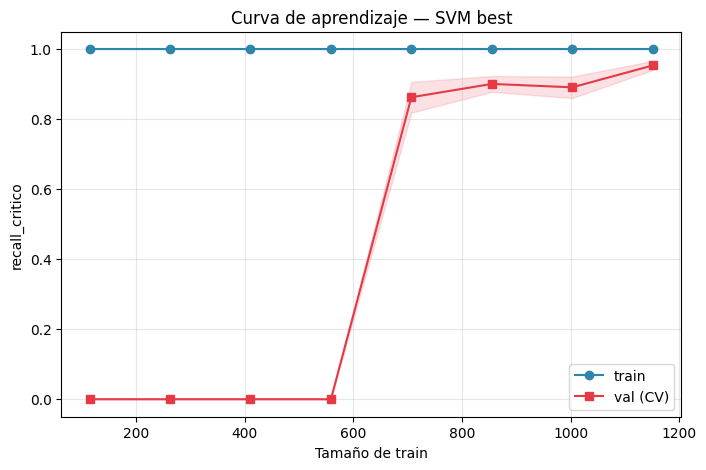

Guardado: reports/figures/08_svm_learning_curve.png


In [20]:
svm_lc_path = FIGURES_DIR / "08_svm_learning_curve.png"
plot_learning_curve(svm_best, "SVM best", svm_lc_path)

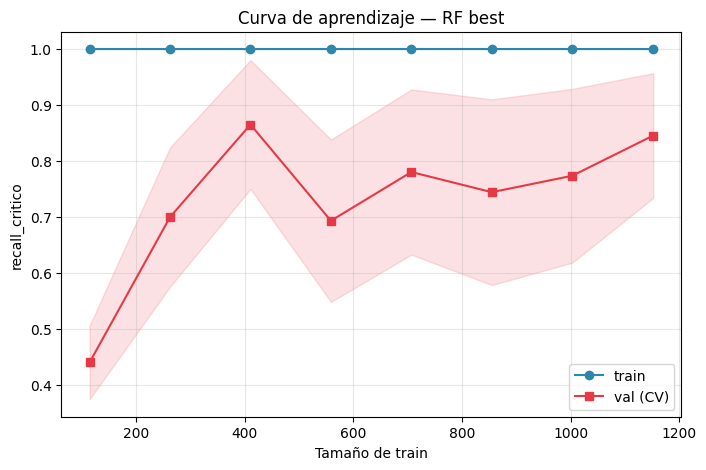

Guardado: reports/figures/08_rf_learning_curve.png


In [21]:
rf_lc_path = FIGURES_DIR / "08_rf_learning_curve.png"
plot_learning_curve(rf_best, "RF best", rf_lc_path)

## 7. Registro en MLflow

In [22]:
def log_model_run(
    run_name: str,
    model_family: str,
    best_params: dict,
    cv_best_score: float,
    metrics_val: dict,
    metrics_holdout: dict,
    model_obj,
    figure_paths: list,
    study: optuna.Study,
) -> None:
    if not MLFLOW_ACTIVE:
        print(f"[MLflow] inactivo — {run_name} no registrado.")
        return

    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tags({
            "model_family": model_family,
            "stage": "advanced_models",
            "validation": "TimeSeriesSplit_5",
            "refit_metric": PRIMARY_METRIC,
        })
        mlflow.log_params(best_params)
        mlflow.log_param("n_features", X_train.shape[1])
        mlflow.log_param("n_train", X_train.shape[0])

        mlflow.log_metric(f"cv_{PRIMARY_METRIC}", cv_best_score)
        for k, v in {**metrics_val, **metrics_holdout}.items():
            mlflow.log_metric(k, float(v))

        for fig_path in figure_paths:
            mlflow.log_artifact(str(fig_path), artifact_path="figures")

        mlflow.sklearn.log_model(model_obj, "model")

        for trial in study.trials:
            if trial.state != optuna.trial.TrialState.COMPLETE:
                continue
            with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
                mlflow.set_tag("model_family", model_family)
                mlflow.set_tag("stage", "optuna_trial")
                mlflow.log_params(trial.params)
                mlflow.log_metric(f"cv_{PRIMARY_METRIC}", trial.value)

        print(f"[MLflow] run registrado: {run.info.run_id}")

In [23]:
log_model_run(
    run_name=f"svm_best_kernel{svm_study.best_params['kernel']}_C{svm_study.best_params['C']:.4f}",
    model_family="svm",
    best_params=svm_study.best_params,
    cv_best_score=svm_study.best_value,
    metrics_val=svm_metrics_val,
    metrics_holdout=svm_metrics_holdout,
    model_obj=svm_best,
    figure_paths=[svm_cm_path, svm_lc_path, svm_hist_path],
    study=svm_study,
)

2026/05/19 18:24:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 18:24:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run trial_0 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2/runs/dc2049e3ab40461ba6993e28b4063324
🧪 View experiment at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2
🏃 View run trial_1 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2/runs/a731eecd120b43938f9db4a72de98e02
🧪 View experiment at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2
🏃 View run trial_2 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2/runs/0b260fa941884b7888c37b2a03b24881
🧪 View experiment at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2
🏃 View run trial_3 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2/runs/8efb54f25eb34a6bb5b7f46e3f3db2c8
🧪 View experiment at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2
🏃 View run trial_4 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2/runs/6d495293b46147a891df78541da200a2
🧪 View experiment at: https://dagshub.com/RovleZM

In [24]:
log_model_run(
    run_name=f"rf_best_n{best_rf_params['n_estimators']}_depth{best_rf_params.get('max_depth', 'None')}",
    model_family="random_forest",
    best_params=best_rf_params,
    cv_best_score=rf_study.best_value,
    metrics_val=rf_metrics_val,
    metrics_holdout=rf_metrics_holdout,
    model_obj=rf_best,
    figure_paths=[rf_cm_path, rf_lc_path, rf_hist_path, rf_fi_path],
    study=rf_study,
)

2026/05/19 18:36:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 18:36:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run trial_0 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2/runs/b0a959a9412f4d07868e200879028060
🧪 View experiment at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2
🏃 View run trial_1 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2/runs/7ea69f789750416b995edbd8067d481d
🧪 View experiment at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2
🏃 View run trial_2 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2/runs/a39b16b9a89f4c7ba673794ddb672228
🧪 View experiment at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2
🏃 View run trial_3 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2/runs/d0e58672449d48a8b3f21583dec7098a
🧪 View experiment at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2
🏃 View run trial_4 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/2/runs/138c4557197141798099beedcfca704d
🧪 View experiment at: https://dagshub.com/RovleZM

## 8. Tabla comparativa LogReg vs SVM vs RF

In [25]:
baseline = {
    "Modelo": "LogReg (baseline)",
    "CV recall_critico":       0.8338,
    "val_recall_critico":      0.837,
    "val_precision_critico":   0.854,
    "val_f1_macro":            0.842,
    "holdout_recall_critico":  0.889,
    "holdout_precision_critico": 0.842,
    "holdout_f1_macro":        0.815,
}

svm_row = {
    "Modelo": "SVM",
    "CV recall_critico": svm_study.best_value,
    **{k: v for k, v in {**svm_metrics_val, **svm_metrics_holdout}.items()
       if any(m in k for m in ["recall_critico", "precision_critico", "f1_macro"])},
}

rf_row = {
    "Modelo": "Random Forest",
    "CV recall_critico": rf_study.best_value,
    **{k: v for k, v in {**rf_metrics_val, **rf_metrics_holdout}.items()
       if any(m in k for m in ["recall_critico", "precision_critico", "f1_macro"])},
}

comparison = pd.DataFrame([baseline, svm_row, rf_row]).set_index("Modelo")
display(comparison.style.highlight_max(axis=0, color="#d4edda").format("{:.3f}"))

,CV recall_critico,val_recall_critico,val_precision_critico,val_f1_macro,holdout_recall_critico,holdout_precision_critico,holdout_f1_macro
Modelo,,,,,,,
LogReg (baseline),0.834,0.837,0.854,0.842,0.889,0.842,0.815
SVM,0.947,0.959,0.427,0.643,1.000,0.353,0.627
Random Forest,0.869,0.939,0.885,0.881,0.889,0.970,0.888


## 9. Versionado con DVC

Correr en terminal después de ejecutar este notebook:

In [26]:
print("Para versionar los modelos con DVC")
print("  dvc add models/svm_best.joblib")
print("  dvc add models/rf_best.joblib")
print("  dvc push")
print()
print("Después:")
print("  git add models/svm_best.joblib.dvc models/rf_best.joblib.dvc .gitignore")
print("  git commit -m 'chore(dvc): versiona svm_best.joblib y rf_best.joblib'")

Para versionar los modelos con DVC (correr en terminal):
  dvc add models/svm_best.joblib
  dvc add models/rf_best.joblib
  dvc push

Después:
  git add models/svm_best.joblib.dvc models/rf_best.joblib.dvc .gitignore
  git commit -m 'chore(dvc): versiona svm_best.joblib y rf_best.joblib'
